# <span style="color:darkslateblue">INTRODUCTION</span>

## 📝 <span style="color:teal">Instructions</span>

This is a <strong>Python Jupyter Notebook</strong> containing both code and rich text elements such as figures, links, equations, etc. The notebook is generally split into the following sections:

1. ✅ <strong>Initial set of pre-filled cells</strong> — run these to load Python modules (packages), the dataset, and its variables into memory.  
2. 📄 <strong>Description of a concrete task</strong> — details about what you're expected to do with the dataset.  
3. 🔍 <strong>Final section</strong> — one or more empty cells where you can:
   - Perform analyses with the dataset  
   - Write code as needed  
   - Answer questions and explain your reasoning  

---

▶️ To run a cell:  
- Click inside the cell and press <code>Shift+Enter</code>  
- OR click the <strong>play</strong> button (🔼) at the top left of the cell  

⏳ It may take a few seconds for output to appear.  

🎉 <span style="color:orange"><strong>Have fun and explore!</strong></span>


In [3]:
# Run the following to import necessary packages and import dataset
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn


train_df = pd.read_csv('train_data.csv')
test_df = pd.read_csv('test_data.csv')
print(train_df.head())
print()
print(test_df.head())

    GPA       salary
0  4.62  5247.290178
1  3.84  3436.752500
2  4.26  4452.452285
3  3.62  3200.222861
4  3.60  3408.427953

    GPA       salary
0  4.62  4571.750846
1  3.84  4085.727432
2  4.26  4058.762669
3  3.62  3697.541085
4  3.60  3513.710537


## 📊 <span style="color:teal">Dataset Description</span>

Each of the 2 dataframes loaded above — <code>train_df</code> and <code>test_df</code> — represents data collected from students including their <strong>GPA</strong> and <strong>monthly salary</strong>.  
The goal of this task is to build predictive models that can estimate a person's <span style="color:green"><strong>salary</strong></span> based on their <span style="color:purple"><strong>GPA</strong></span> using <code>train_df</code>. Then, evaluate the performance of these models using the unseen data in <code>test_df</code>.  

🎯 Feel free to try out different modelling techniques. There's no single "correct" way to solve this problem, so <span style="color:orange"><strong>be creative!</strong></span>

---

## ✅ <span style="color:lime">Evaluate and Reflect</span>

Once you've trained your models and made predictions using the test set, take a moment to reflect on your results. Answer the following questions:

- <span style="color:darkred"><strong>Which model performed the best?</strong></span>  
- <span style="color:darkred"><strong>Why do you think it is the best model?</strong></span>  

📝 <em>(Fill in your answers in the markdown cell at the bottom of the notebook)</em>


In [7]:
# Write your code here
# Feel free to add new cells if needed

X_train = train_df["GPA"]
y_train = train_df["salary"]
X_test = test_df["GPA"]
y_test = test_df["salary"]

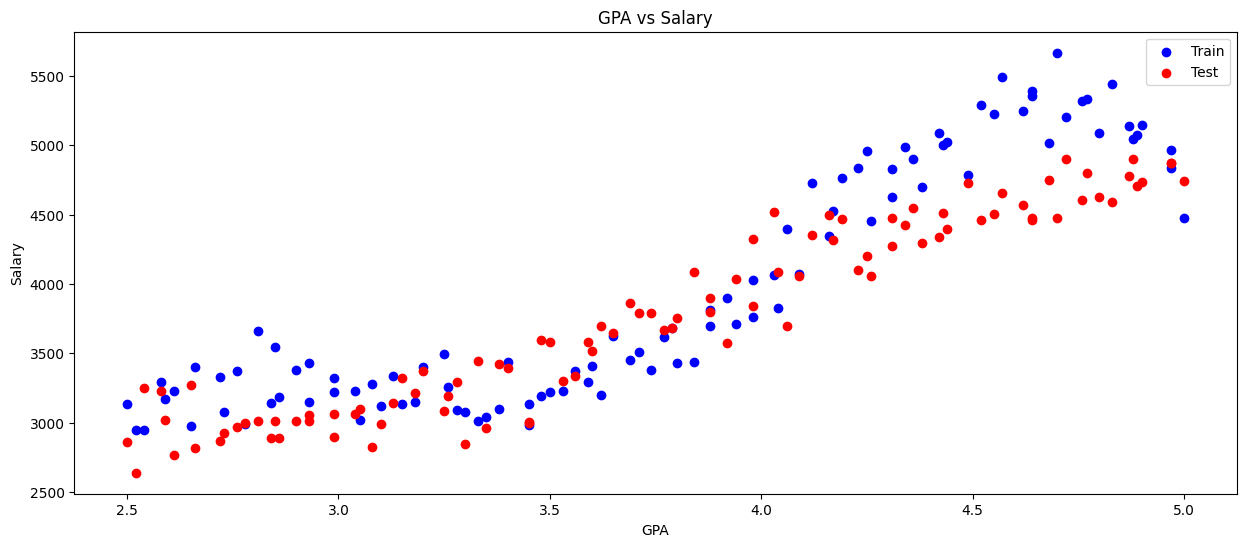

In [10]:
plt.figure(figsize=(15,6))

# Plotting the training data
plt.scatter(X_train, y_train, color='blue', label='Train')

# Plotting the testing data
plt.scatter(X_test, y_test, color='red', label='Test')

plt.xlabel('GPA')
plt.ylabel('Salary')
plt.title('GPA vs Salary')
plt.legend()
plt.show()


In [59]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

def get_predictions(degree):
    # Polynomial transformation
    poly = PolynomialFeatures(degree=degree)
    X_poly_train = poly.fit_transform(X_train.values.reshape(-1, 1))
    X_poly_test = poly.transform(X_test.values.reshape(-1, 1))

    # Scale the polynomial features
    scaler_X = StandardScaler()
    X_poly_train_scaled = scaler_X.fit_transform(X_poly_train)
    X_poly_test_scaled = scaler_X.transform(X_poly_test)

    # Fit linear regression
    model = LinearRegression()
    model.fit(X_poly_train_scaled, y_train.values)

    # Predict
    y_pred_train = model.predict(X_poly_train_scaled)
    y_pred_test = model.predict(X_poly_test_scaled)

    # Compute percentage error
    percentage_difference_train = np.mean(np.abs((y_pred_train - y_train.values) / y_train.values * 100))
    percentage_difference_test = np.mean(np.abs((y_pred_test - y_test.values) / y_test.values * 100))

    print(f'Train percentage error for degree {degree} = {percentage_difference_train}')
    print(f'Test percentage error for degree {degree} = {percentage_difference_test}\n')
    
    return y_pred_train, y_pred_test, percentage_difference_test

    

y_pred_train_2, y_pred_test_2, percentage_difference_2 = get_predictions(2)
y_pred_train_3, y_pred_test_3, percentage_difference_3 = get_predictions(3)
y_pred_train_4, y_pred_test_4, percentage_difference_4 = get_predictions(4)
y_pred_train_5, y_pred_test_5, percentage_difference_5 = get_predictions(5)

Train percentage error for degree 2 = 6.316836614489856
Test percentage error for degree 2 = 6.469096271988695

Train percentage error for degree 3 = 5.796773210959332
Test percentage error for degree 3 = 6.830595317166146

Train percentage error for degree 4 = 3.401112554156717
Test percentage error for degree 4 = 8.422801438299869

Train percentage error for degree 5 = 3.400565031608382
Test percentage error for degree 5 = 8.423430057271585



In [60]:
# fig, axs = plt.subplots(2, 1, figsize=(12, 6))

# axs[0].scatter(X_train, y_train, color='blue', label='Train')
# axs[0].scatter(X_train, y_pred_train_1, color='red', label='Train predictions')
# axs[0].set_xlabel('GPA')
# axs[0].set_ylabel('salary')
# axs[0].set_title('Train')

# axs[1].scatter(X_test, y_test, color='blue', label='Test')
# axs[1].scatter(X_test, y_pred_test_1, color='red', label='Test predictions')
# axs[1].set_xlabel('GPA')
# axs[1].set_ylabel('salary')
# axs[1].set_title('Test')

In [61]:
print(f'Degree 2: {percentage_difference_2}')
print(f'Degree 3: {percentage_difference_3}')
print(f'Degree 4: {percentage_difference_4}')
print(f'Degree 5: {percentage_difference_5}')

Degree 2: 6.469096271988695
Degree 3: 6.830595317166146
Degree 4: 8.422801438299869
Degree 5: 8.423430057271585


## 🧾 <span style="color:slateblue">Write Your Answers Here</span>

1️⃣ <span style="color:darkred"><strong>Which is the best model that you have created?</strong></span>  
&nbsp;&nbsp;&nbsp;&nbsp;- Briefly describe the model 

2️⃣ <span style="color:darkred"><strong>Why is that model the best?</strong></span>  
&nbsp;&nbsp;&nbsp;&nbsp;- What criteria did you use to evaluate it?   
&nbsp;&nbsp;&nbsp;&nbsp;- Mention any advantages over other models you tried
